Porownaj trening z i bez early_stopping.<br>
Wymagania:<br>
Dataset: Breast Cancer <br>
Architektura: (64, 32), solver='adam', max_iter=1000 <br>
Wariant 1: early_stopping=False <br>
Wariant 2: early_stopping=True, validation_fraction=0.15<br>
Porownaj: epoki, czas, accuracy<br>
Oczekiwany wynik:<br>
Tabela porownawcza i wykresy loss<br>

In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Wariant bez early stopping
start = time.time()

model_no_es = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    solver='adam',
    max_iter=1000,
    early_stopping=False,
    random_state=42
)

model_no_es.fit(X_train, y_train)

time_no_es = time.time() - start

y_pred = model_no_es.predict(X_test)
acc_no_es = accuracy_score(y_test, y_pred)

epochs_no_es = model_no_es.n_iter_
loss_no_es = model_no_es.loss_curve_

#Wariant z early stopping
start = time.time()

model_es = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    solver='adam',
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42
)

model_es.fit(X_train, y_train)

time_es = time.time() - start

y_pred = model_es.predict(X_test)
acc_es = accuracy_score(y_test, y_pred)

epochs_es = model_es.n_iter_

#Tabela porównawcza
results = pd.DataFrame({
    "Model": ["Bez early stopping", "Z early stopping"],
    "Epoki": [epochs_no_es, epochs_es],
    "Czas treningu (s)": [time_no_es, time_es],
    "Accuracy": [acc_no_es, acc_es]
})

print(results)
loss_es = model_es.loss_curve_


                Model  Epoki  Czas treningu (s)  Accuracy
0  Bez early stopping    155           0.445122  0.973684
1    Z early stopping     29           0.075076  0.964912


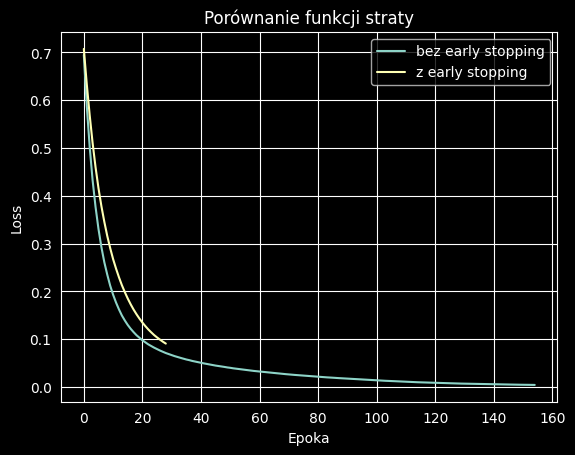

In [3]:
plt.figure()

plt.plot(loss_no_es, label="bez early stopping")
plt.plot(loss_es, label="z early stopping")

plt.xlabel("Epoka")
plt.ylabel("Loss")
plt.title("Porównanie funkcji straty")
plt.legend()

plt.show()